# 🏠 EcoPredict — Prédiction Énergétique des Logements (DPE)
**Objectif** : Prédire la consommation énergétique (kWh/m²/an), les émissions de CO₂ (kg CO₂/m²/an) et le coût annuel estimé d'un logement à partir des données DPE.

**Stack** : Python 3.12+ · Pandas · Scikit-learn · XGBoost · Matplotlib / Seaborn

In [19]:
# ============================================================
# CELLULE 1 — Installation des dépendances
# ============================================================
!pip install -q xgboost scikit-learn pandas matplotlib seaborn optuna

In [20]:
# ============================================================
# CELLULE 2 — Imports
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid", palette="viridis")
pd.set_option("display.max_columns", 80)
print("✅ Imports OK (avec Optuna + SciPy)")

✅ Imports OK (avec Optuna + SciPy)


---
## 1 · Chargement & Nettoyage des données

In [21]:
# ============================================================
# CELLULE 3 — Montage Drive + Chargement CSV
# ============================================================
# Montage Google Drive (décommenter si exécution sur Colab)
# from google.colab import drive
# drive.mount('/content/drive')

# Chemin Colab (adapter si nécessaire)
DATA_PATH = "dpe_logement.csv"

df_raw = pd.read_csv(DATA_PATH, sep=";", low_memory=False)
print(f"Dataset brut : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes")
df_raw.head(3)

Dataset brut : 146,462 lignes × 105 colonnes


,identifiant_dpe,code_departement_insee,arrete_2021,type_dpe,type_batiment_dpe,periode_construction_dpe,annee_construction_dpe,version,date_etablissement_dpe,date_reception_dpe,nombre_niveau_logement,nombre_niveau_immeuble,surface_habitable_immeuble,surface_habitable_logement,conso_5_usages_ep_m2,conso_5_usages_ef_m2,emission_ges_5_usages_m2,classe_bilan_dpe,classe_emission_ges,classe_conso_energie_arrete_2012,classe_emission_ges_arrete_2012,conso_3_usages_ep_m2_arrete_2012,emission_ges_3_usages_ep_m2_arrete_2012,type_installation_chauffage,type_energie_chauffage,type_generateur_chauffage,type_generateur_chauffage_anciennete,type_energie_chauffage_appoint,type_generateur_chauffage_appoint,type_generateur_chauffage_anciennete_appoint,chauffage_solaire,nb_generateur_chauffage,nb_installation_chauffage,type_energie_climatisation,type_generateur_climatisation,type_generateur_climatisation_anciennete,type_installation_ecs,type_energie_ecs,type_generateur_ecs,type_generateur_ecs_anciennete,...,l_orientation_baie_vitree,pourcentage_surface_baie_vitree_exterieur,type_isolation_mur_exterieur,epaisseur_isolation_mur_exterieur_estim,materiaux_structure_mur_exterieur,epaisseur_structure_mur_exterieur,surface_mur_totale,surface_mur_exterieur,surface_mur_deperditif,u_mur_exterieur,l_local_non_chauffe_mur,local_non_chauffe_principal_mur,l_orientation_mur_exterieur,type_isolation_plancher_bas,type_plancher_bas_deperditif,surface_plancher_bas_totale,surface_plancher_bas_deperditif,u_plancher_bas_final_deperditif,u_plancher_bas_brut_deperditif,l_local_non_chauffe_plancher_bas,local_non_chauffe_principal_plancher_bas,type_adjacence_principal_plancher_bas,type_isolation_plancher_haut,type_plancher_haut_deperditif,surface_plancher_haut_totale,surface_plancher_haut_deperditif,u_plancher_haut_deperditif,l_local_non_chauffe_plancher_haut,local_non_chauffe_principal_plancher_haut,type_adjacence_principal_plancher_haut,type_porte,surface_porte,u_porte,classe_inertie,deperdition_mur,deperdition_baie_vitree,deperdition_plancher_bas,deperdition_plancher_haut,deperdition_pont_thermique,deperdition_porte
0,1101V1000001P,1,0,dpe arrêté 2012 3cl logement,appartement,1948-1974,1969.0,NaN,NaN,2015/06/17 00:00:00,NaN,NaN,NaN,110.0,NaN,NaN,NaN,NaN,NaN,E,C,260.04,13.92,individuel,electricite,chaudiere electrique,NaN,electricite,generateurs a effet joule,NaN,0.0,NaN,NaN,NaN,NaN,NaN,individuel,electricite,ballon accumulation electrique,NaN,...,"[ ""nord"", ""sud"" ]",0.275,non isole,NaN,NaN,NaN,21.7,21.7,21.7,2.0,NaN,NaN,NaN,non isole,NaN,20.0,20.0,1.0,NaN,NaN,NaN,NaN,ITE,NaN,20.05,20.05,1.0,NaN,NaN,NaN,NaN,NaN,NaN,Moyenne,NaN,NaN,NaN,NaN,NaN,NaN
1,1101V2000001Q,1,0,dpe arrêté 2012 facture logement,appartement,1948-1974,1948.0,NaN,NaN,2014/11/17 00:00:00,NaN,NaN,NaN,47.0,NaN,NaN,NaN,NaN,NaN,C,A,118.54,1.84,collectif,gaz,chaudiere gaz standard,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,individuel,gaz,chaudiere gaz standard,NaN,...,NaN,NaN,isole,NaN,murs en béton banché,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,non isole,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,non isole,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1201L2000001Q,1,0,dpe arrêté 2012 facture logement,maison,1948-1974,1948.0,NaN,NaN,2016/11/07 00:00:00,NaN,NaN,NaN,55.0,NaN,NaN,NaN,NaN,NaN,N,N,0.00,0.00,NaN,electricite,generateurs a effet joule,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,individuel,electricite,ballon accumulation electrique,NaN,...,NaN,NaN,isole,NaN,murs en pierre de taille et moellons constitué...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,non isole,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,non isole,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
# ============================================================
# CELLULE 4 — Sélection ÉTENDUE des colonnes utiles
# ============================================================

# --- Features numériques directes ---
FEATURES_NUM_RAW = [
    "surface_habitable_logement",
    "annee_construction_dpe",
    "nombre_niveau_logement",
    "nombre_niveau_immeuble",
    "surface_habitable_immeuble",
]

# --- Features numériques supplémentaires (enveloppe thermique) ---
FEATURES_NUM_ENVELOPE = [
    "surface_mur_totale",
    "surface_mur_exterieur",
    "surface_mur_deperditif",
    "u_mur_exterieur",
    "surface_plancher_bas_totale",
    "surface_plancher_bas_deperditif",
    "surface_plancher_haut_totale",
    "surface_plancher_haut_deperditif",
    "u_baie_vitree",
    "facteur_solaire_baie_vitree",
]

# --- Features numériques vitrages (orientations) ---
FEATURES_NUM_VITRAGE = [
    "surface_vitree_nord",
    "surface_vitree_sud",
    "surface_vitree_ouest",
    "surface_vitree_est",
]

FEATURES_NUM_ALL = FEATURES_NUM_RAW + FEATURES_NUM_ENVELOPE + FEATURES_NUM_VITRAGE

# --- Features catégorielles ---
FEATURES_CAT = [
    "type_batiment_dpe",              # maison / appartement
    "type_energie_chauffage",         # gaz, electricite, fioul, bois...
    "type_installation_chauffage",    # individuel / collectif
    "type_generateur_chauffage",      # chaudière, PAC, convecteurs...
    "type_energie_ecs",               # eau chaude sanitaire
    "type_generateur_ecs",            # ballon, chaudière...
    "type_installation_ecs",          # individuel / collectif
    "type_isolation_mur_exterieur",   # ITI, ITE, non isole...
    "type_isolation_plancher_bas",    # isolation plancher bas
    "type_isolation_plancher_haut",   # isolation plancher haut
    "materiaux_structure_mur_exterieur",  # béton, brique, pierre...
    "type_vitrage",                   # simple, double, triple
    "type_materiaux_menuiserie",      # bois, PVC, alu...
    "type_gaz_lame",                  # air, argon...
    "type_ventilation",               # VMC, naturelle...
    "periode_construction_dpe",       # tranche de construction
    "chauffage_solaire",              # 0/1
    "ecs_solaire",                    # 0/1
    "traversant",                     # logement traversant
    "presence_balcon",                # présence de balcon
    "classe_inertie",                 # légère, moyenne, lourde
]

# --- Colonnes cibles (arrêté 2012) ---
TARGETS = [
    "conso_3_usages_ep_m2_arrete_2012",
    "emission_ges_3_usages_ep_m2_arrete_2012",
]

COLS = FEATURES_NUM_ALL + FEATURES_CAT + TARGETS
df = df_raw[COLS].copy()
print(f"✅ Colonnes retenues : {len(COLS)} (vs 10 précédemment)")
print(f"   → {len(FEATURES_NUM_ALL)} numériques + {len(FEATURES_CAT)} catégorielles + {len(TARGETS)} cibles")
df.info(verbose=False)

✅ Colonnes retenues : 42 (vs 10 précédemment)
   → 19 numériques + 21 catégorielles + 2 cibles
<class 'pandas.DataFrame'>
RangeIndex: 146462 entries, 0 to 146461
Columns: 42 entries, surface_habitable_logement to emission_ges_3_usages_ep_m2_arrete_2012
dtypes: float64(24), str(18)
memory usage: 46.9 MB


In [30]:
# ============================================================
# CELLULE 5 — Nettoyage avancé + IQR + Feature Engineering
# ============================================================

print("=" * 60)
print("PHASE 1 — NETTOYAGE DE BASE")
print("=" * 60)

# 5a — Valeurs manquantes
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
print("📊 Top 15 colonnes avec valeurs manquantes (%) :")
print(missing_pct[missing_pct > 0].sort_values(ascending=False).head(15))

# Supprimer lignes sans cible
df.dropna(subset=TARGETS, inplace=True)
print(f"\nAprès suppression lignes sans cible : {len(df):,}")

# Features numériques manquantes → médiane
for col in FEATURES_NUM_ALL:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

# Features catégorielles manquantes → "inconnu"
for col in FEATURES_CAT:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna("inconnu")

# ⚠️ CRITIQUE : forcer TOUTES les colonnes catégorielles en str
# Certaines colonnes (chauffage_solaire, ecs_solaire, traversant, presence_balcon)
# contiennent des valeurs numériques (0/1) ou des NaN flottants résiduels.
# OrdinalEncoder rejette tout mélange float+str → on cast en str uniformément.
for col in FEATURES_CAT:
    df[col] = df[col].astype(str).str.strip()
    # Normaliser les NaN qui passent en string "nan" ou "NaN"
    df[col] = df[col].replace({"nan": "inconnu", "NaN": "inconnu", "None": "inconnu", "": "inconnu"})

print(f"\nColonnes catégorielles castées en str (types mixtes corrigés)")

# 5b — Filtrage physique de base (avant IQR)
n_before = len(df)
df = df[df["surface_habitable_logement"].between(9, 500)]
df = df[df["annee_construction_dpe"].between(1800, 2025)]
df = df[df["conso_3_usages_ep_m2_arrete_2012"] > 0]
df = df[df["emission_ges_3_usages_ep_m2_arrete_2012"] >= 0]
print(f"Après filtrage physique : {len(df):,} (supprimé {n_before - len(df):,})")

print("\n" + "=" * 60)
print("PHASE 2 — DÉTECTION D'OUTLIERS (IQR)")
print("=" * 60)

def remove_outliers_iqr(dataframe, column, k=1.5):
    """Supprime les outliers via IQR sur une colonne donnée."""
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    before = len(dataframe)
    dataframe = dataframe[dataframe[column].between(lower, upper)]
    removed = before - len(dataframe)
    print(f"  {column}: Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f} → "
          f"bornes [{lower:.1f}, {upper:.1f}] → {removed:,} outliers supprimés")
    return dataframe

# IQR sur consommation et émissions (k=1.5 standard)
df = remove_outliers_iqr(df, "conso_3_usages_ep_m2_arrete_2012", k=1.5)
df = remove_outliers_iqr(df, "emission_ges_3_usages_ep_m2_arrete_2012", k=1.5)
df = remove_outliers_iqr(df, "surface_habitable_logement", k=2.0)  # plus tolérant

print("\n" + "=" * 60)
print("PHASE 3 — FILTRAGE DES INCOHÉRENCES THERMIQUES")
print("=" * 60)

n_before = len(df)

# Incohérence 1 : Logements post-2012 avec conso > 250 kWh (aberrant RT2012)
mask_rt2012_bad = (
    (df["annee_construction_dpe"] >= 2013) &
    (df["conso_3_usages_ep_m2_arrete_2012"] > 250)
)
print(f"  Post-2012 avec conso > 250 kWh : {mask_rt2012_bad.sum():,} lignes supprimées")
df = df[~mask_rt2012_bad]

# Incohérence 2 : Logements pré-1950 avec conso < 50 kWh (bruit)
mask_old_classA = (
    (df["annee_construction_dpe"] < 1950) &
    (df["conso_3_usages_ep_m2_arrete_2012"] < 50)
)
print(f"  Pré-1950 avec conso < 50 kWh   : {mask_old_classA.sum():,} lignes supprimées")
df = df[~mask_old_classA]

print(f"\n  Total incohérences supprimées   : {n_before - len(df):,}")

print("\n" + "=" * 60)
print("PHASE 4 — FEATURE ENGINEERING")
print("=" * 60)

# 4a — Variable binaire RT2012
df["is_rt2012"] = (df["annee_construction_dpe"] >= 2013).astype(int)
print("  ✅ is_rt2012 : logement post-2012 (RT2012/RE2020)")

# 4b — Âge du bâtiment
df["age_batiment"] = 2026 - df["annee_construction_dpe"]
print("  ✅ age_batiment : 2026 - année_construction")

# 4c — Surface totale vitrée
df["surface_vitree_totale"] = (
    df["surface_vitree_nord"] + df["surface_vitree_sud"] +
    df["surface_vitree_ouest"] + df["surface_vitree_est"]
)
print("  ✅ surface_vitree_totale : somme 4 orientations")

# 4d — Ratio surface vitrée / surface habitable
df["ratio_vitrage"] = (
    df["surface_vitree_totale"] / df["surface_habitable_logement"].clip(lower=1)
).round(4)
print("  ✅ ratio_vitrage : surface_vitrée / surface_habitable")

# 4e — Ratio mur déperditif / mur total
df["ratio_mur_deperditif"] = (
    df["surface_mur_deperditif"] / df["surface_mur_totale"].clip(lower=1)
).clip(0, 1).round(4)
print("  ✅ ratio_mur_deperditif : murs perdants / murs totaux")

# 4f — Surface par niveau
df["surface_par_niveau"] = (
    df["surface_habitable_logement"] / df["nombre_niveau_logement"].clip(lower=1)
).round(2)
print("  ✅ surface_par_niveau : surface / nb_niveaux")

# 4g — Compacité estimée
df["compacite"] = (
    df["surface_mur_exterieur"] / df["surface_habitable_logement"].clip(lower=1)
).round(4)
print("  ✅ compacite : surface_mur_ext / surface_hab")

# 4h — Coût annuel avec tarifs réels 2025-2026
TARIFS_ENERGIE = {
    "electricite": 0.2516,
    "gaz":         0.1284,
    "fioul":       0.1190,
    "bois":        0.0700,
    "charbon":     0.0900,
    "gpl":         0.1550,
    "reseau":      0.1050,
}
TARIF_DEFAULT = 0.15

def get_tarif(energie_str):
    if pd.isna(energie_str) or str(energie_str).lower() in ("nan", "inconnu", ""):
        return TARIF_DEFAULT
    e = str(energie_str).lower().strip()
    for key, tarif in TARIFS_ENERGIE.items():
        if key in e:
            return tarif
    return TARIF_DEFAULT

def coef_ep_ef(energie_str):
    if pd.isna(energie_str):
        return 1.0
    e = str(energie_str).lower().strip()
    if "electri" in e:
        return 1 / 2.3
    return 1.0

df["tarif_kwh"] = df["type_energie_chauffage"].apply(get_tarif)
df["coef_ep_ef"] = df["type_energie_chauffage"].apply(coef_ep_ef)
df["cout_annuel_estim"] = (
    df["conso_3_usages_ep_m2_arrete_2012"]
    * df["coef_ep_ef"]
    * df["surface_habitable_logement"]
    * df["tarif_kwh"]
).round(2)

print("  ✅ cout_annuel_estim : tarifs réels 2025 + conversion EP→EF")

# Liste finale des features engineered
FEATURES_ENGINEERED = [
    "is_rt2012",
    "age_batiment",
    "surface_vitree_totale",
    "ratio_vitrage",
    "ratio_mur_deperditif",
    "surface_par_niveau",
    "compacite",
]

FEATURES_NUM = FEATURES_NUM_ALL + FEATURES_ENGINEERED

print(f"\n✅ Dataset final : {df.shape[0]:,} lignes")
print(f"   Features : {len(FEATURES_NUM)} num + {len(FEATURES_CAT)} cat = {len(FEATURES_NUM) + len(FEATURES_CAT)}")
print(f"\n📊 Statistiques cibles :")
display(df[TARGETS + ["cout_annuel_estim"]].describe().round(2))

PHASE 1 — NETTOYAGE DE BASE
📊 Top 15 colonnes avec valeurs manquantes (%) :
nombre_niveau_immeuble                     88.12
surface_habitable_immeuble                 78.85
conso_3_usages_ep_m2_arrete_2012           59.19
emission_ges_3_usages_ep_m2_arrete_2012    59.19
surface_vitree_nord                        48.13
surface_vitree_est                         44.37
surface_vitree_sud                         44.02
surface_vitree_ouest                       44.01
surface_plancher_bas_deperditif            43.38
surface_plancher_haut_deperditif           42.31
nombre_niveau_logement                     42.29
surface_plancher_bas_totale                32.91
surface_plancher_haut_totale               32.19
u_mur_exterieur                            26.77
facteur_solaire_baie_vitree                26.26
dtype: float64

Après suppression lignes sans cible : 59,774

Colonnes catégorielles castées en str (types mixtes corrigés)
Après filtrage physique : 49,590 (supprimé 10,184)

PHASE 2 — DÉT

,conso_3_usages_ep_m2_arrete_2012,emission_ges_3_usages_ep_m2_arrete_2012,cout_annuel_estim
count,45132.00,45132.00,45132.00
mean,201.75,25.18,2099.39
std,96.61,17.48,1271.88
min,0.17,0.00,2.86
25%,129.88,11.63,1152.88
50%,196.00,20.03,1884.14
75%,266.98,36.00,2797.59
max,506.17,77.95,13067.17


---
## 2 · Analyse Exploratoire (EDA)

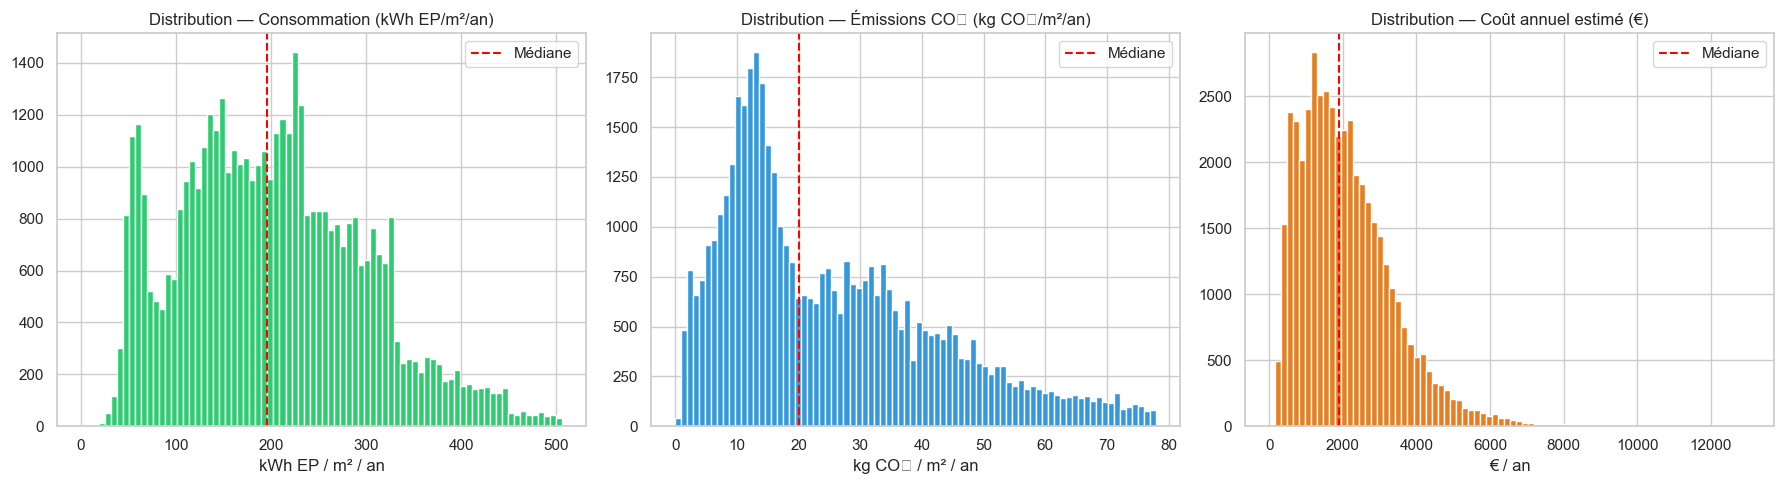

In [31]:
# ============================================================
# CELLULE 6 — Distribution des variables cibles
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Consommation énergétique
axes[0].hist(df["conso_3_usages_ep_m2_arrete_2012"], bins=80, color="#2ecc71", edgecolor="white")
axes[0].set_title("Distribution — Consommation (kWh EP/m²/an)", fontsize=12)
axes[0].set_xlabel("kWh EP / m² / an")
axes[0].axvline(df["conso_3_usages_ep_m2_arrete_2012"].median(), color="red", ls="--", label="Médiane")
axes[0].legend()

# Émissions GES
axes[1].hist(df["emission_ges_3_usages_ep_m2_arrete_2012"], bins=80, color="#3498db", edgecolor="white")
axes[1].set_title("Distribution — Émissions CO₂ (kg CO₂/m²/an)", fontsize=12)
axes[1].set_xlabel("kg CO₂ / m² / an")
axes[1].axvline(df["emission_ges_3_usages_ep_m2_arrete_2012"].median(), color="red", ls="--", label="Médiane")
axes[1].legend()

# Coût annuel estimé
axes[2].hist(df["cout_annuel_estim"], bins=80, color="#e67e22", edgecolor="white")
axes[2].set_title("Distribution — Coût annuel estimé (€)", fontsize=12)
axes[2].set_xlabel("€ / an")
axes[2].axvline(df["cout_annuel_estim"].median(), color="red", ls="--", label="Médiane")
axes[2].legend()

plt.tight_layout()
plt.show()

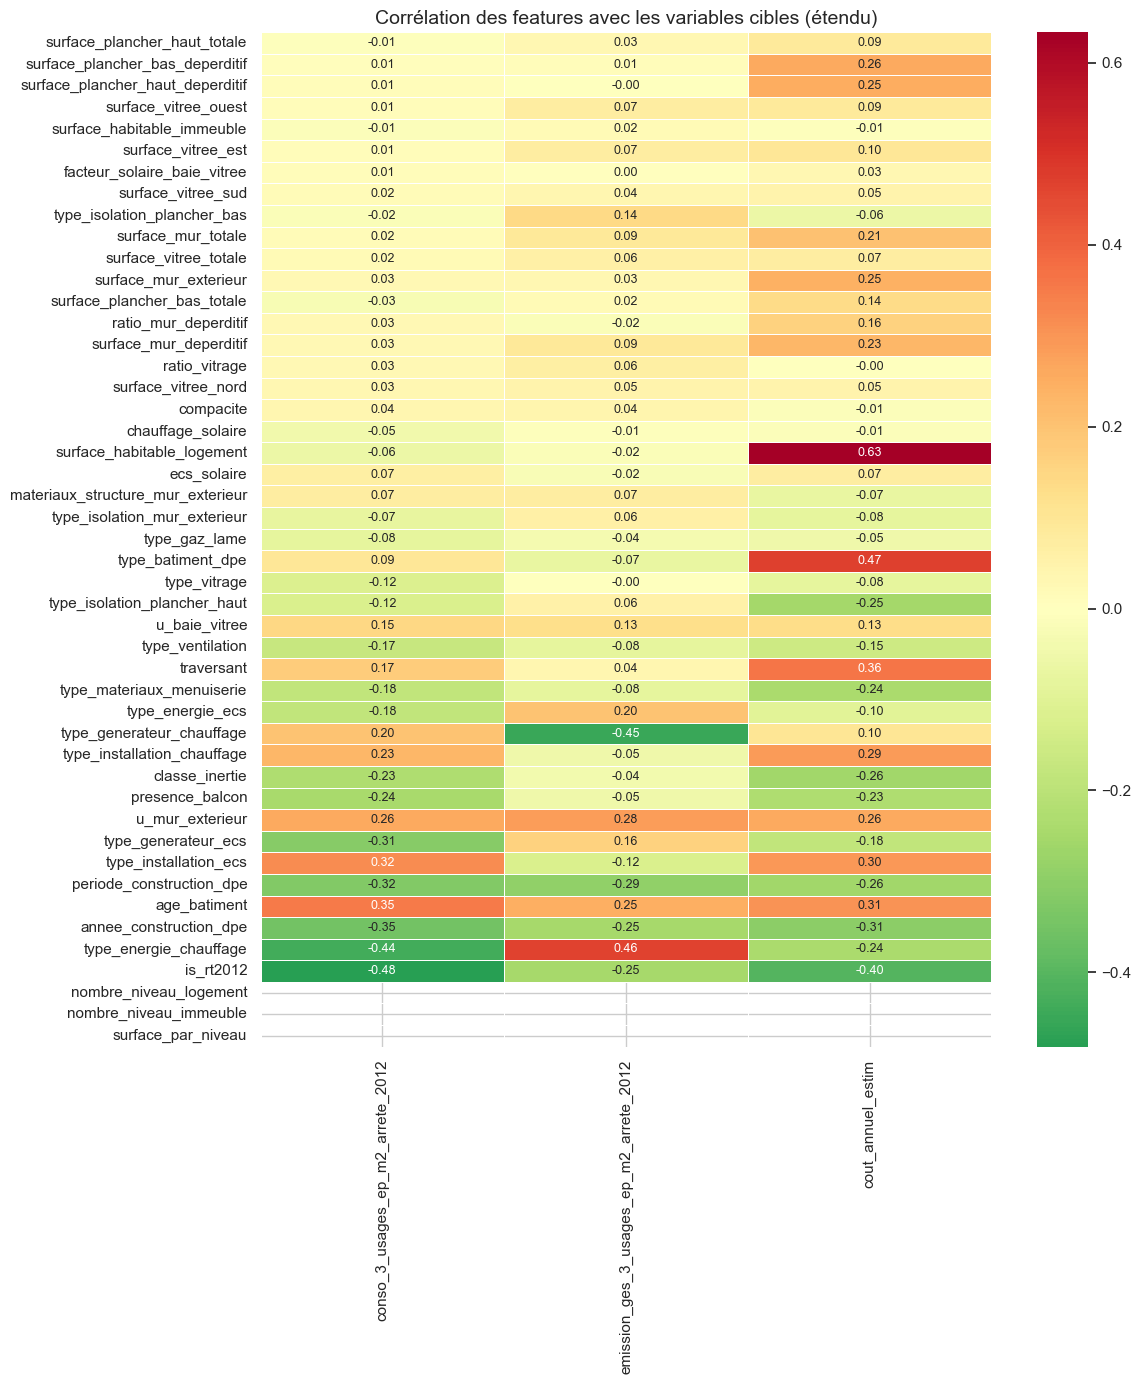

In [32]:
# ============================================================
# CELLULE 7 — Matrice de corrélation ciblée (features étendues)
# ============================================================
df_corr = df.copy()
for col in FEATURES_CAT:
    df_corr[col] = df_corr[col].astype("category").cat.codes

corr_cols = FEATURES_NUM + FEATURES_CAT + TARGETS + ["cout_annuel_estim"]
corr_matrix = df_corr[corr_cols].corr()

# Corrélations avec les 3 cibles uniquement
targets_display = TARGETS + ["cout_annuel_estim"]
target_corr = corr_matrix[targets_display].drop(index=targets_display, errors="ignore")

# Trier par corrélation absolue avec la consommation
target_corr = target_corr.reindex(
    target_corr[TARGETS[0]].abs().sort_values(ascending=True).index
)

fig, ax = plt.subplots(figsize=(12, 14))
sns.heatmap(
    target_corr,
    annot=True, fmt=".2f", cmap="RdYlGn_r",
    center=0, linewidths=0.5, ax=ax,
    annot_kws={"size": 9}
)
ax.set_title("Corrélation des features avec les variables cibles (étendu)", fontsize=14)
plt.tight_layout()
plt.show()

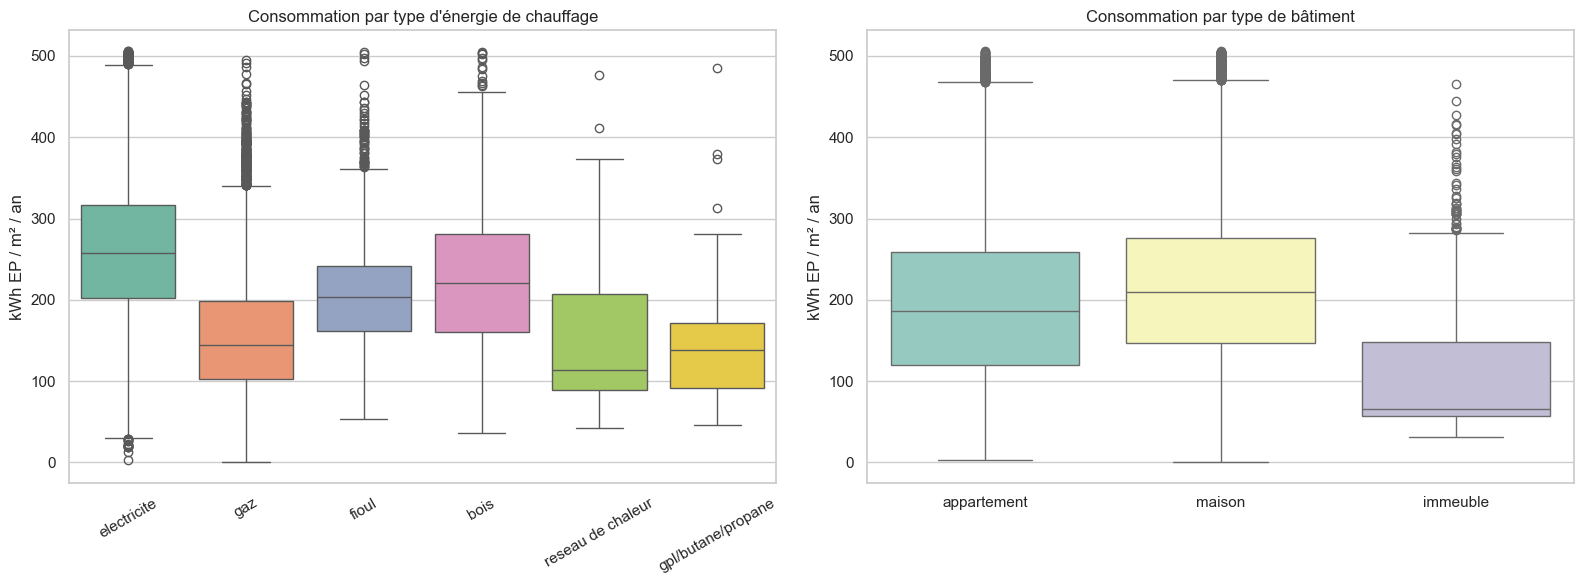

In [33]:
# ============================================================
# CELLULE 8 — Consommation par type d'énergie & type de bâtiment
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Par énergie de chauffage
top_energies = df["type_energie_chauffage"].value_counts().head(6).index
sns.boxplot(
    data=df[df["type_energie_chauffage"].isin(top_energies)],
    x="type_energie_chauffage", y="conso_3_usages_ep_m2_arrete_2012",
    ax=axes[0], palette="Set2"
)
axes[0].set_title("Consommation par type d'énergie de chauffage")
axes[0].set_xlabel("")
axes[0].set_ylabel("kWh EP / m² / an")
axes[0].tick_params(axis="x", rotation=30)

# Par type de bâtiment
sns.boxplot(
    data=df,
    x="type_batiment_dpe", y="conso_3_usages_ep_m2_arrete_2012",
    ax=axes[1], palette="Set3"
)
axes[1].set_title("Consommation par type de bâtiment")
axes[1].set_xlabel("")
axes[1].set_ylabel("kWh EP / m² / an")

plt.tight_layout()
plt.show()

---
## 3 · Modélisation — XGBoost MultiOutput Pipeline

In [34]:
# ============================================================
# CELLULE 9 — Préparation X / y + Train/Test Split
# ============================================================

# Features = numériques étendues + catégorielles
ALL_FEATURES = FEATURES_NUM + FEATURES_CAT
X = df[ALL_FEATURES].copy()

# Targets : consommation + émissions CO2 + coût annuel calibré
y = df[TARGETS + ["cout_annuel_estim"]].copy()
TARGET_NAMES = [
    "Consommation (kWh/m²/an)",
    "Émissions CO₂ (kg/m²/an)",
    "Coût annuel (€)",
]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Features : {X.shape[1]} ({len(FEATURES_NUM)} num + {len(FEATURES_CAT)} cat)")
print(f"Train    : {X_train.shape[0]:,} lignes")
print(f"Test     : {X_test.shape[0]:,} lignes")

Features : 47 (26 num + 21 cat)
Train    : 36,105 lignes
Test     : 9,027 lignes


In [37]:
# ============================================================
# CELLULE 10 — Pipeline + Optimisation Optuna (~1-2 min RTX 3060 Ti)
# ============================================================

# Preprocessor commun
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), FEATURES_NUM),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
         FEATURES_CAT),
    ]
)

# --- Optuna objective ---
def optuna_objective(trial):
    """Objective Optuna — R² 3-Fold CV sur la consommation."""
    params = {
        # Arbres limités à 400 max : suffisant avec GPU, évite l'explosion du temps
        "n_estimators":    trial.suggest_int("n_estimators", 100, 400, step=50),
        "max_depth":       trial.suggest_int("max_depth", 4, 10),
        "learning_rate":   trial.suggest_float("learning_rate", 0.02, 0.15, log=True),
        "subsample":       trial.suggest_float("subsample", 0.6, 0.95),
        "colsample_bytree":trial.suggest_float("colsample_bytree", 0.5, 0.95),
        "reg_alpha":       trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        "reg_lambda":      trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
        "min_child_weight":trial.suggest_int("min_child_weight", 1, 15),
    }

    xgb = XGBRegressor(
        **params,
        tree_method="hist",
        device="cuda",     # RTX 3060 Ti
        random_state=42,
        verbosity=0,
    )

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", xgb),
    ])

    # 3-Fold CV (au lieu de 5) — 40% plus rapide, variance acceptable sur >100k lignes
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(
        pipe, X_train, y_train.iloc[:, 0],
        cv=kf, scoring="r2",
        n_jobs=1,          # OBLIGATOIRE avec GPU : 1 seul job, pas de conflit CUDA
    )
    return scores.mean()

# --- Lancement Optuna ---
# 20 trials × 3 folds × ~400 arbres ≈ 1-2 min sur RTX 3060 Ti
N_TRIALS = 20
print(f"🔍 Optimisation Optuna ({N_TRIALS} trials, 3-Fold CV, GPU)...")

study = optuna.create_study(
    direction="maximize",
    study_name="ecopredict_v2",
    sampler=optuna.samplers.TPESampler(seed=42),  # TPE = meilleure exploration par trial
)
study.optimize(optuna_objective, n_trials=N_TRIALS, show_progress_bar=True)

best = study.best_params
print(f"\n✅ Meilleur R² CV : {study.best_value:.4f}")
print("📋 Hyperparamètres optimaux :")
for k, v in best.items():
    print(f"   {k}: {v}")

🔍 Optimisation Optuna (20 trials, 3-Fold CV, GPU)...


Best trial: 14. Best value: 0.776687: 100%|██████████| 20/20 [02:04<00:00,  6.22s/it]


✅ Meilleur R² CV : 0.7767
📋 Hyperparamètres optimaux :
   n_estimators: 350
   max_depth: 10
   learning_rate: 0.05445154015249903
   subsample: 0.8177538768291722
   colsample_bytree: 0.5059131420730139
   reg_alpha: 0.01823649070813702
   reg_lambda: 0.00112356147589739
   min_child_weight: 15


In [38]:
# ============================================================
# CELLULE 11 — Entraînement final MultiOutput (single pass)
# ============================================================

xgb_best = XGBRegressor(
    **best,
    tree_method="hist",
    device="cuda",
    random_state=42,
    verbosity=0,
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", MultiOutputRegressor(xgb_best, n_jobs=1)),  # n_jobs=1 : GPU unique
])

pipeline.fit(X_train, y_train)
print("✅ Modèle final entraîné (MultiOutput XGBoost optimisé)")

✅ Modèle final entraîné (MultiOutput XGBoost optimisé)


---
## 4 · Évaluation & Visualisation

In [39]:
# ============================================================
# CELLULE 12 — Métriques R², MAE, RMSE
# ============================================================
y_pred = pipeline.predict(X_test)

print("=" * 60)
print("📈 MÉTRIQUES D'ÉVALUATION SUR LE JEU DE TEST")
print("=" * 60)

metrics_rows = []
for i, name in enumerate(TARGET_NAMES):
    r2  = r2_score(y_test.iloc[:, i], y_pred[:, i])
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    metrics_rows.append({"Cible": name, "R²": round(r2, 4), "MAE": round(mae, 2), "RMSE": round(rmse, 2)})
    print(f"\n🎯 {name}")
    print(f"   R²   = {r2:.4f}")
    print(f"   MAE  = {mae:.2f}")
    print(f"   RMSE = {rmse:.2f}")

metrics_df = pd.DataFrame(metrics_rows)
print("\n")
display(metrics_df)

📈 MÉTRIQUES D'ÉVALUATION SUR LE JEU DE TEST

🎯 Consommation (kWh/m²/an)
   R²   = 0.7835
   MAE  = 29.58
   RMSE = 44.94

🎯 Émissions CO₂ (kg/m²/an)
   R²   = 0.8155
   MAE  = 4.52
   RMSE = 7.50

🎯 Coût annuel (€)
   R²   = 0.8259
   MAE  = 320.80
   RMSE = 527.92




,Cible,R²,MAE,RMSE
0,Consommation (kWh/m²/an),0.7835,29.58,44.94
1,Émissions CO₂ (kg/m²/an),0.8155,4.52,7.50
2,Coût annuel (€),0.8259,320.80,527.92


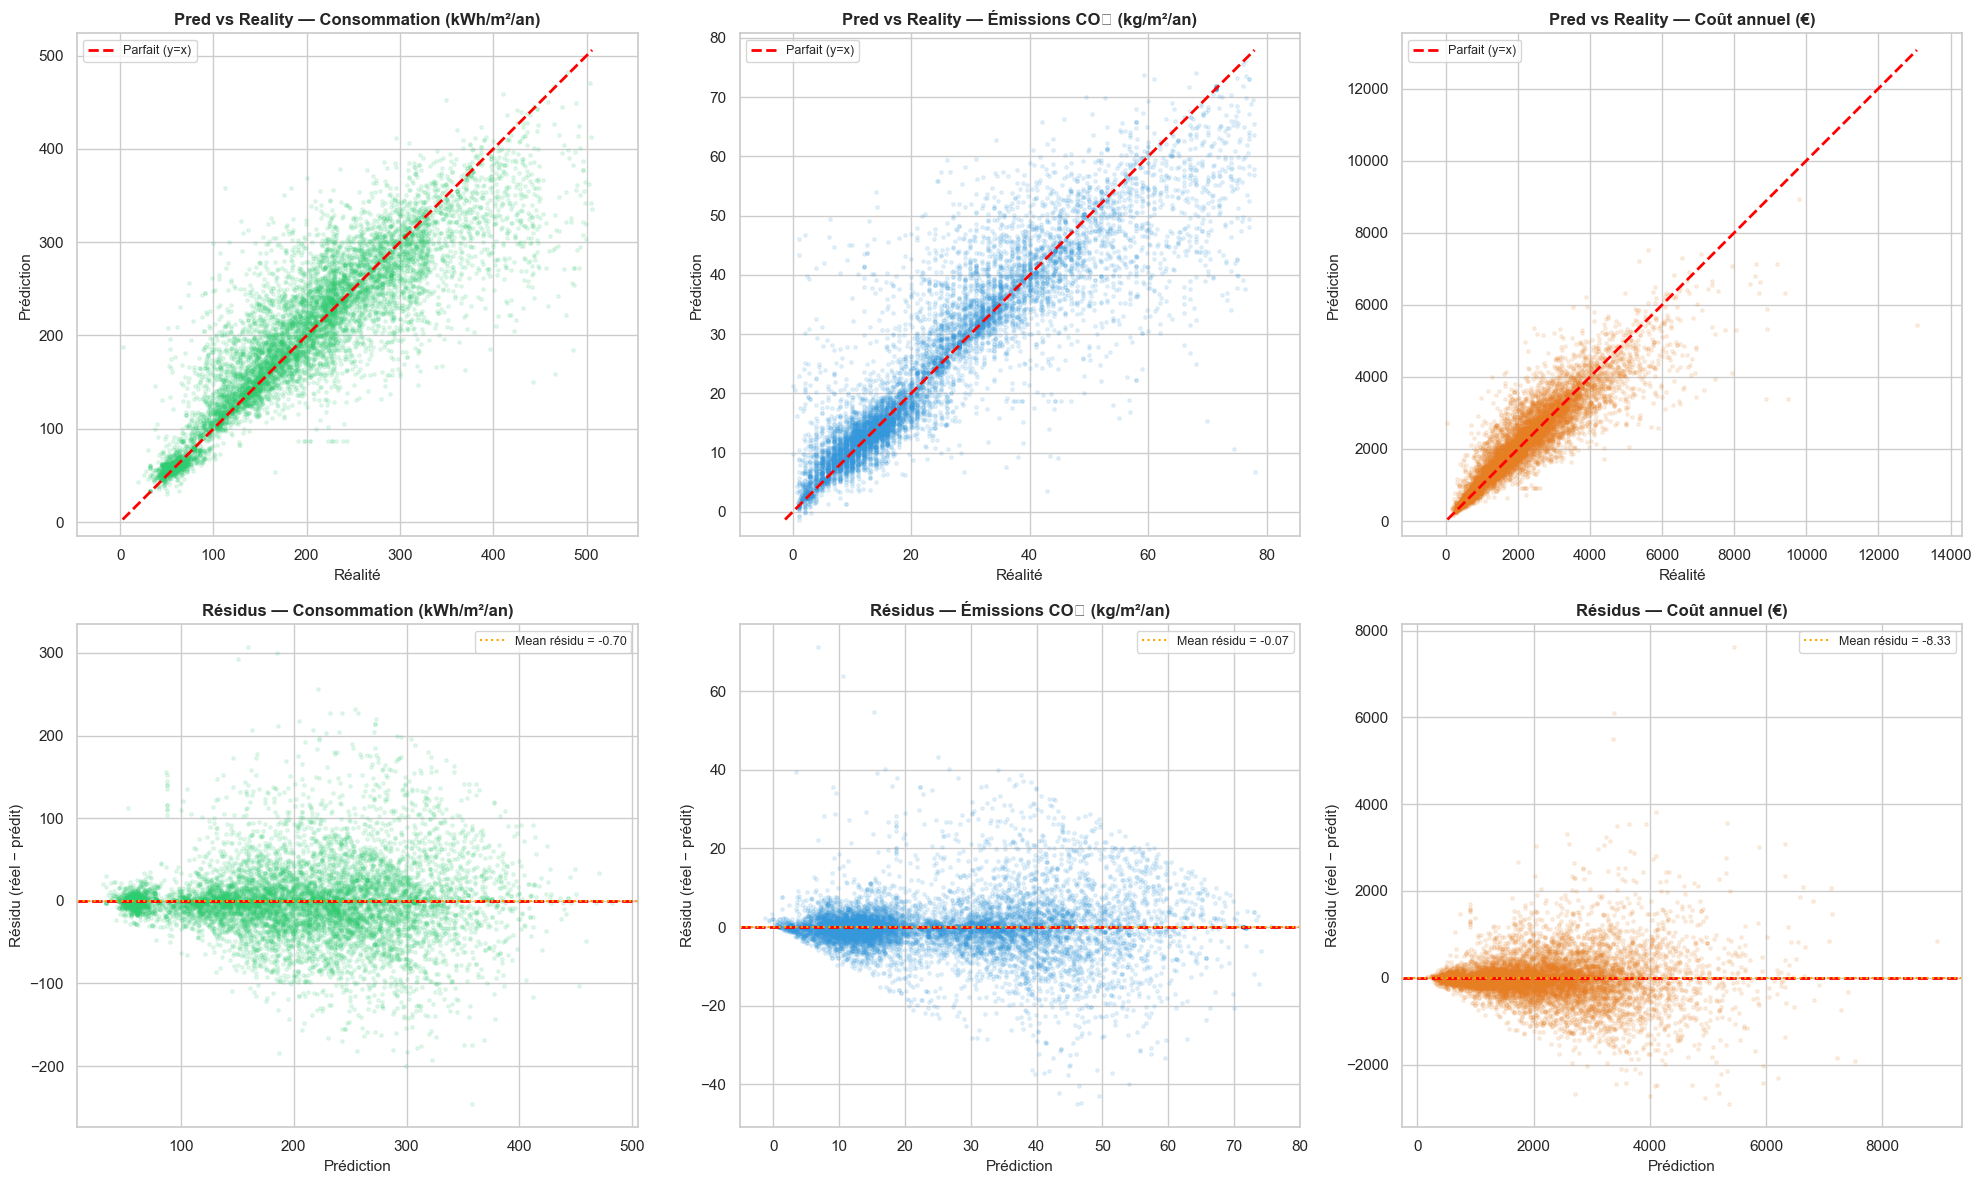

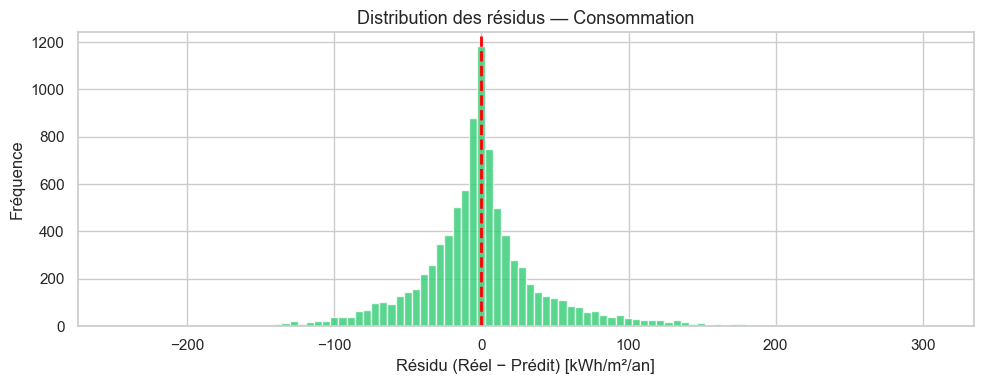

📊 Résidus Consommation : mean=-0.70, std=44.94, median=-1.51


In [40]:
# ============================================================
# CELLULE 13 — Predictions vs Reality + Residuals Plot
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

colors = ["#2ecc71", "#3498db", "#e67e22"]

for i, (name, color) in enumerate(zip(TARGET_NAMES, colors)):
    y_true_i = y_test.iloc[:, i].values
    y_pred_i = y_pred[:, i]
    residuals = y_true_i - y_pred_i

    # --- Row 1 : Pred vs Reality ---
    axes[0, i].scatter(y_true_i, y_pred_i, alpha=0.12, s=6, color=color)
    lims = [
        min(y_true_i.min(), y_pred_i.min()),
        max(y_true_i.max(), y_pred_i.max()),
    ]
    axes[0, i].plot(lims, lims, "r--", lw=2, label="Parfait (y=x)")
    axes[0, i].set_xlabel("Réalité", fontsize=11)
    axes[0, i].set_ylabel("Prédiction", fontsize=11)
    axes[0, i].set_title(f"Pred vs Reality — {name}", fontsize=12, fontweight="bold")
    axes[0, i].legend(fontsize=9)
    axes[0, i].set_aspect("equal", adjustable="datalim")

    # --- Row 2 : Residuals Plot ---
    axes[1, i].scatter(y_pred_i, residuals, alpha=0.12, s=6, color=color)
    axes[1, i].axhline(0, color="red", ls="--", lw=2)
    axes[1, i].axhline(residuals.mean(), color="orange", ls=":", lw=1.5,
                        label=f"Mean résidu = {residuals.mean():.2f}")
    axes[1, i].set_xlabel("Prédiction", fontsize=11)
    axes[1, i].set_ylabel("Résidu (réel − prédit)", fontsize=11)
    axes[1, i].set_title(f"Résidus — {name}", fontsize=12, fontweight="bold")
    axes[1, i].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Distribution des résidus sur la consommation
fig, ax = plt.subplots(figsize=(10, 4))
residuals_conso = y_test.iloc[:, 0].values - y_pred[:, 0]
ax.hist(residuals_conso, bins=100, color="#2ecc71", edgecolor="white", alpha=0.8)
ax.axvline(0, color="red", ls="--", lw=2)
ax.set_xlabel("Résidu (Réel − Prédit) [kWh/m²/an]")
ax.set_title("Distribution des résidus — Consommation", fontsize=13)
ax.set_ylabel("Fréquence")
plt.tight_layout()
plt.show()

print(f"📊 Résidus Consommation : mean={residuals_conso.mean():.2f}, "
      f"std={residuals_conso.std():.2f}, "
      f"median={np.median(residuals_conso):.2f}")

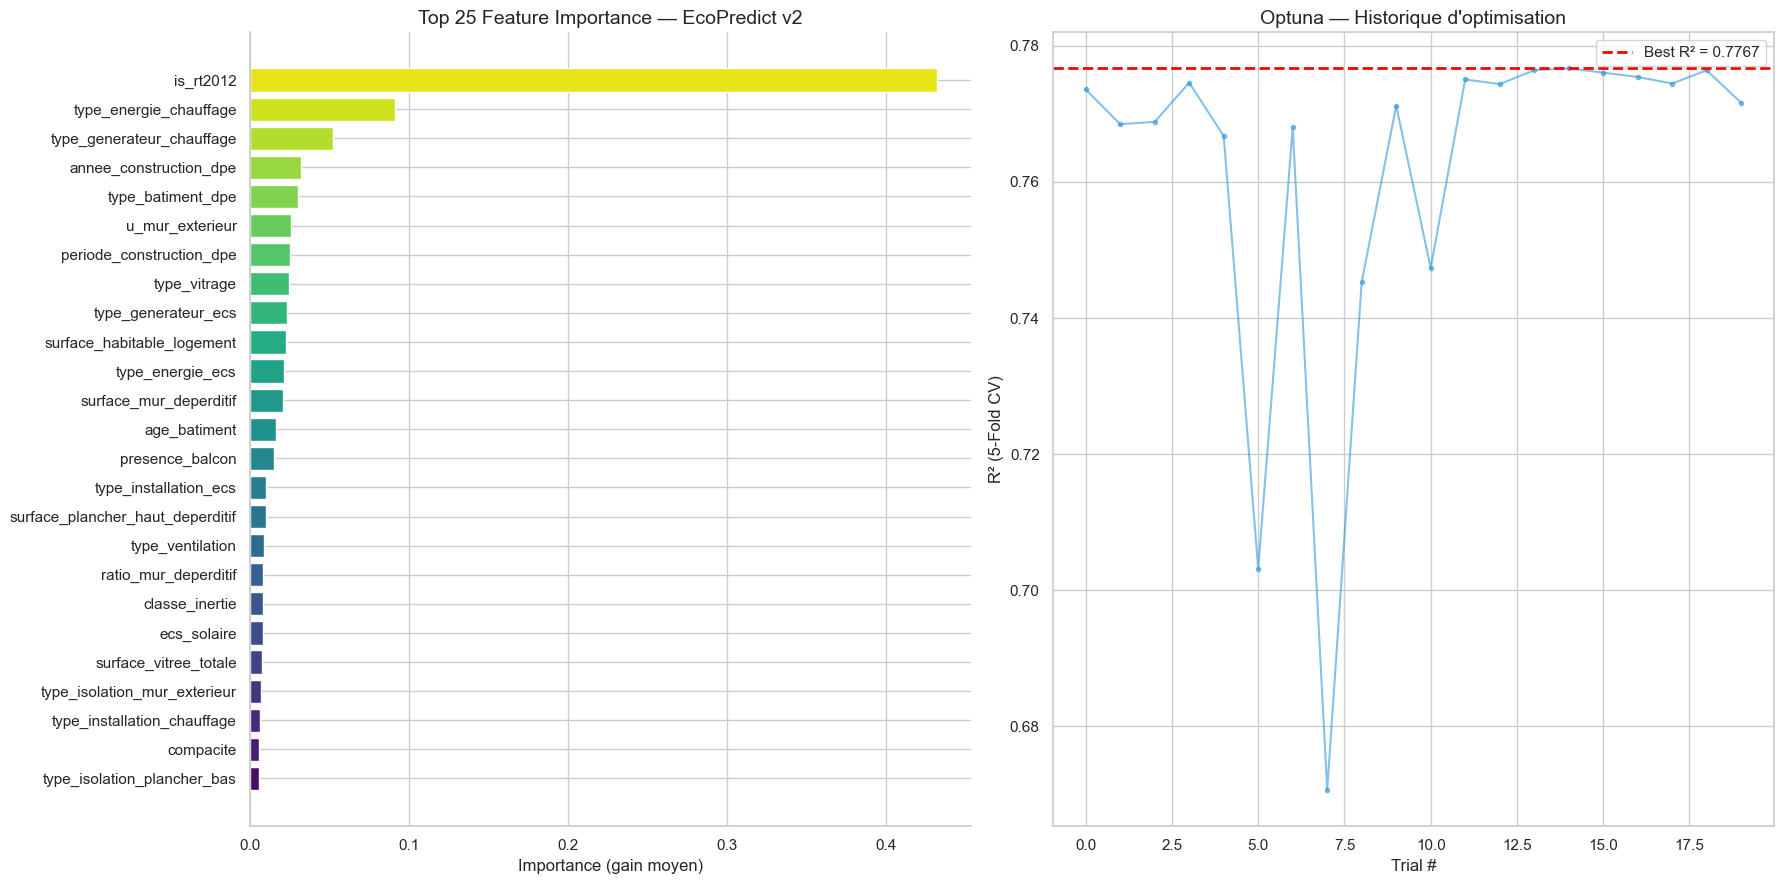


📊 Top 10 features les plus influentes :
  is_rt2012                                → 0.4321
  type_energie_chauffage                   → 0.0911
  type_generateur_chauffage                → 0.0524
  annee_construction_dpe                   → 0.0323
  type_batiment_dpe                        → 0.0302
  u_mur_exterieur                          → 0.0255
  periode_construction_dpe                 → 0.0253
  type_vitrage                             → 0.0244
  type_generateur_ecs                      → 0.0234
  surface_habitable_logement               → 0.0225


In [41]:
# ============================================================
# CELLULE 14 — Feature Importance (top 25) + Optuna history
# ============================================================
feature_names = FEATURES_NUM + FEATURES_CAT

# Importance moyenne sur les 3 estimateurs XGBoost
importances = np.mean(
    [est.feature_importances_ for est in pipeline.named_steps["model"].estimators_],
    axis=0,
)

fi_df = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
    .sort_values("Importance", ascending=True)
    .tail(25)  # Top 25
)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Feature importance
axes[0].barh(fi_df["Feature"], fi_df["Importance"],
             color=sns.color_palette("viridis", len(fi_df)))
axes[0].set_xlabel("Importance (gain moyen)", fontsize=12)
axes[0].set_title("Top 25 Feature Importance — EcoPredict v2", fontsize=14)
for spine in ["top", "right"]:
    axes[0].spines[spine].set_visible(False)

# Optuna optimization history
trials_df = study.trials_dataframe()
axes[1].plot(trials_df["number"], trials_df["value"], "o-",
             markersize=3, alpha=0.6, color="#3498db")
axes[1].axhline(study.best_value, color="red", ls="--", lw=2,
                label=f"Best R² = {study.best_value:.4f}")
axes[1].set_xlabel("Trial #", fontsize=12)
axes[1].set_ylabel("R² (5-Fold CV)", fontsize=12)
axes[1].set_title("Optuna — Historique d'optimisation", fontsize=14)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("\n📊 Top 10 features les plus influentes :")
for _, row in fi_df.sort_values("Importance", ascending=False).head(10).iterrows():
    print(f"  {row['Feature']:40s} → {row['Importance']:.4f}")

---
## 5 · Interface de Simulation — `predict_energy()`

In [ ]:
# ============================================================
# CELLULE 15 — Fonction de prédiction EcoPredict v2
# ============================================================
def predict_energy(
    surface: float,
    annee: int,
    nb_niveaux: int = 1,
    nb_niveaux_immeuble: float = 0,
    surface_immeuble: float = 0,
    # --- Enveloppe thermique ---
    surface_mur_totale: float = 0,
    surface_mur_exterieur: float = 0,
    surface_mur_deperditif: float = 0,
    u_mur_exterieur: float = 0,
    surface_plancher_bas_totale: float = 0,
    surface_plancher_bas_deperditif: float = 0,
    surface_plancher_haut_totale: float = 0,
    surface_plancher_haut_deperditif: float = 0,
    u_baie_vitree: float = 0,
    facteur_solaire_baie_vitree: float = 0,
    # --- Vitrages ---
    surface_vitree_nord: float = 0,
    surface_vitree_sud: float = 0,
    surface_vitree_ouest: float = 0,
    surface_vitree_est: float = 0,
    # --- Catégorielles ---
    type_batiment: str = "maison",
    type_energie_chauffage: str = "gaz",
    type_installation_chauffage: str = "individuel",
    type_generateur_chauffage: str = "inconnu",
    type_energie_ecs: str = "inconnu",
    type_generateur_ecs: str = "inconnu",
    type_installation_ecs: str = "inconnu",
    type_isolation_mur: str = "ITI",
    type_isolation_plancher_bas: str = "inconnu",
    type_isolation_plancher_haut: str = "inconnu",
    materiaux_mur: str = "inconnu",
    type_vitrage: str = "double vitrage",
    type_menuiserie: str = "inconnu",
    type_gaz_lame: str = "inconnu",
    type_ventilation: str = "Ventilation mécanique auto réglable",
    periode_construction: str = "1975-1977",
    chauffage_solaire: str = "0",
    ecs_solaire: str = "0",
    traversant: str = "inconnu",
    presence_balcon: str = "inconnu",
    classe_inertie: str = "inconnu",
) -> dict:
    """
    Prédit la consommation, émissions CO₂ et coût annuel.
    Tous les paramètres d'enveloppe sont optionnels (défaut = 0 / inconnu).
    """

    # Features engineered
    is_rt2012 = 1 if annee >= 2013 else 0
    age_batiment = 2026 - annee
    surface_vitree_totale = surface_vitree_nord + surface_vitree_sud + surface_vitree_ouest + surface_vitree_est
    ratio_vitrage = surface_vitree_totale / max(surface, 1)
    ratio_mur_dep = surface_mur_deperditif / max(surface_mur_totale, 1) if surface_mur_totale > 0 else 0
    surface_par_niv = surface / max(nb_niveaux, 1)
    compacite_val = surface_mur_exterieur / max(surface, 1) if surface_mur_exterieur > 0 else 0

    input_df = pd.DataFrame([{
        # Num raw
        "surface_habitable_logement": surface,
        "annee_construction_dpe": annee,
        "nombre_niveau_logement": nb_niveaux,
        "nombre_niveau_immeuble": nb_niveaux_immeuble,
        "surface_habitable_immeuble": surface_immeuble,
        # Num envelope
        "surface_mur_totale": surface_mur_totale,
        "surface_mur_exterieur": surface_mur_exterieur,
        "surface_mur_deperditif": surface_mur_deperditif,
        "u_mur_exterieur": u_mur_exterieur,
        "surface_plancher_bas_totale": surface_plancher_bas_totale,
        "surface_plancher_bas_deperditif": surface_plancher_bas_deperditif,
        "surface_plancher_haut_totale": surface_plancher_haut_totale,
        "surface_plancher_haut_deperditif": surface_plancher_haut_deperditif,
        "u_baie_vitree": u_baie_vitree,
        "facteur_solaire_baie_vitree": facteur_solaire_baie_vitree,
        # Num vitrage
        "surface_vitree_nord": surface_vitree_nord,
        "surface_vitree_sud": surface_vitree_sud,
        "surface_vitree_ouest": surface_vitree_ouest,
        "surface_vitree_est": surface_vitree_est,
        # Engineered
        "is_rt2012": is_rt2012,
        "age_batiment": age_batiment,
        "surface_vitree_totale": surface_vitree_totale,
        "ratio_vitrage": round(ratio_vitrage, 4),
        "ratio_mur_deperditif": round(ratio_mur_dep, 4),
        "surface_par_niveau": round(surface_par_niv, 2),
        "compacite": round(compacite_val, 4),
        # Cat
        "type_batiment_dpe": type_batiment,
        "type_energie_chauffage": type_energie_chauffage,
        "type_installation_chauffage": type_installation_chauffage,
        "type_generateur_chauffage": type_generateur_chauffage,
        "type_energie_ecs": type_energie_ecs,
        "type_generateur_ecs": type_generateur_ecs,
        "type_installation_ecs": type_installation_ecs,
        "type_isolation_mur_exterieur": type_isolation_mur,
        "type_isolation_plancher_bas": type_isolation_plancher_bas,
        "type_isolation_plancher_haut": type_isolation_plancher_haut,
        "materiaux_structure_mur_exterieur": materiaux_mur,
        "type_vitrage": type_vitrage,
        "type_materiaux_menuiserie": type_menuiserie,
        "type_gaz_lame": type_gaz_lame,
        "type_ventilation": type_ventilation,
        "periode_construction_dpe": periode_construction,
        "chauffage_solaire": chauffage_solaire,
        "ecs_solaire": ecs_solaire,
        "traversant": traversant,
        "presence_balcon": presence_balcon,
        "classe_inertie": classe_inertie,
    }])

    pred = pipeline.predict(input_df)[0]

    # Cast float32 → Python float pour un arrondi propre
    conso = round(float(pred[0]), 1)
    co2   = round(float(pred[1]), 1)
    cout_model = round(float(pred[2]), 2)

    # Coût annuel recalculé avec tarifs réels
    tarif = get_tarif(type_energie_chauffage)
    coef = coef_ep_ef(type_energie_chauffage)
    cout_reel = round(float(pred[0]) * coef * surface * tarif, 2)

    result = {
        "consommation_kwh_m2_an": conso,
        "emission_co2_kg_m2_an": co2,
        "cout_annuel_euros": cout_reel,
        "cout_annuel_modele": cout_model,
        "classe_energie": _classe_dpe(conso),
        "classe_ges": _classe_ges(co2),
    }

    print("=" * 55)
    print("🏠 RÉSULTAT ECOPREDICT v2")
    print("=" * 55)
    print(f"  Surface           : {surface} m²")
    print(f"  Année             : {annee} ({'RT2012+' if is_rt2012 else 'pré-RT2012'})")
    print(f"  Bâtiment          : {type_batiment}")
    print(f"  Chauffage         : {type_energie_chauffage} ({type_installation_chauffage})")
    print(f"  Isolation murs    : {type_isolation_mur}")
    print(f"  Tarif énergie     : {tarif} €/kWh ({type_energie_chauffage})")
    print("-" * 55)
    print(f"  📊 Consommation    : {conso:>8} kWh/m²/an")
    print(f"  🌿 Émissions CO₂   : {co2:>8} kg CO₂/m²/an")
    print(f"  💰 Coût annuel     : {cout_reel:>8} €/an")
    print(f"  🏷️  Classe Énergie  : {result['classe_energie']}")
    print(f"  🏷️  Classe GES      : {result['classe_ges']}")
    print("=" * 55)

    return result


def _classe_dpe(conso: float) -> str:
    """Classe DPE arrêté 2012."""
    if conso <= 50:   return "A"
    if conso <= 90:   return "B"
    if conso <= 150:  return "C"
    if conso <= 230:  return "D"
    if conso <= 330:  return "E"
    if conso <= 450:  return "F"
    return "G"


def _classe_ges(ges: float) -> str:
    """Classe GES arrêté 2012."""
    if ges <= 5:   return "A"
    if ges <= 10:  return "B"
    if ges <= 20:  return "C"
    if ges <= 35:  return "D"
    if ges <= 55:  return "E"
    if ges <= 80:  return "F"
    return "G"


print("✅ Fonction predict_energy() v2 prête")

✅ Fonction predict_energy() v2 prête


In [43]:
# ============================================================
# CELLULE 16 — Tests de simulation v2
# ============================================================

# Test 1 : Appartement ancien, gaz collectif, passoire thermique
print("🔹 TEST 1 — Appartement 1965, gaz collectif, non isolé")
_ = predict_energy(
    surface=65, annee=1965,
    type_batiment="appartement",
    type_energie_chauffage="gaz",
    type_installation_chauffage="collectif",
    type_generateur_chauffage="chaudiere classique gaz",
    type_energie_ecs="gaz",
    type_installation_ecs="collectif",
    type_isolation_mur="non isole",
    type_vitrage="simple vitrage",
    type_ventilation="Ventilation par ouverture des fenêtres",
    periode_construction="1948-1974",
    materiaux_mur="beton",
    classe_inertie="lourde",
)

print("\n")

# Test 2 : Maison RT2012, PAC électrique, bien isolée
print("🔹 TEST 2 — Maison 2018, PAC élec, ITE, RE2020-ready")
_ = predict_energy(
    surface=120, annee=2018,
    type_batiment="maison",
    type_energie_chauffage="electricite",
    type_installation_chauffage="individuel",
    type_generateur_chauffage="pac air/eau",
    type_energie_ecs="electricite",
    type_generateur_ecs="ballon thermodynamique",
    type_installation_ecs="individuel",
    type_isolation_mur="ITE",
    type_isolation_plancher_bas="isole",
    type_isolation_plancher_haut="isole",
    type_vitrage="double vitrage",
    type_menuiserie="pvc",
    type_gaz_lame="argon",
    type_ventilation="Ventilation mécanique double flux avec échangeur",
    periode_construction="2013-2021",
    materiaux_mur="beton",
    classe_inertie="moyenne",
)

print("\n")

# Test 3 : Maison fioul années 80
print("🔹 TEST 3 — Maison 1982, fioul, isolation intérieure")
_ = predict_energy(
    surface=95, annee=1982,
    type_batiment="maison",
    type_energie_chauffage="fioul",
    type_installation_chauffage="individuel",
    type_generateur_chauffage="chaudiere classique fioul",
    type_energie_ecs="fioul",
    type_installation_ecs="individuel",
    type_isolation_mur="ITI",
    type_vitrage="double vitrage",
    type_ventilation="Ventilation mécanique auto réglable",
    periode_construction="1978-1982",
    materiaux_mur="parpaing",
    classe_inertie="moyenne",
)

print("\n")

# Test 4 : Appartement récent BBC
print("🔹 TEST 4 — Appartement 2015, gaz condensation, BBC")
_ = predict_energy(
    surface=55, annee=2015,
    nb_niveaux=1,
    nb_niveaux_immeuble=5,
    type_batiment="appartement",
    type_energie_chauffage="gaz",
    type_installation_chauffage="individuel",
    type_generateur_chauffage="chaudiere condensation gaz",
    type_energie_ecs="gaz",
    type_generateur_ecs="chaudiere condensation gaz",
    type_installation_ecs="individuel",
    type_isolation_mur="ITE",
    type_isolation_plancher_bas="isole",
    type_isolation_plancher_haut="isole",
    type_vitrage="double vitrage",
    type_menuiserie="pvc",
    type_gaz_lame="argon",
    type_ventilation="Ventilation mécanique à extraction et entrées d'air hygroréglables",
    periode_construction="2013-2021",
    materiaux_mur="beton",
    classe_inertie="lourde",
)

🔹 TEST 1 — Appartement 1965, gaz collectif, non isolé
🏠 RÉSULTAT ECOPREDICT v2
  Surface           : 65 m²
  Année             : 1965 (pré-RT2012)
  Bâtiment          : appartement
  Chauffage         : gaz (collectif)
  Isolation murs    : non isole
  Tarif énergie     : 0.1284 €/kWh (gaz)
-------------------------------------------------------
  📊 Consommation    : 168.0500030517578 kWh/m²/an
  🌿 Émissions CO₂   : 39.529998779296875 kg CO₂/m²/an
  💰 Coût annuel     : 1402.56005859375 €/an
  🏷️  Classe Énergie  : D
  🏷️  Classe GES      : E


🔹 TEST 2 — Maison 2018, PAC élec, ITE, RE2020-ready
🏠 RÉSULTAT ECOPREDICT v2
  Surface           : 120 m²
  Année             : 2018 (RT2012+)
  Bâtiment          : maison
  Chauffage         : electricite (individuel)
  Isolation murs    : ITE
  Tarif énergie     : 0.2516 €/kWh (electricite)
-------------------------------------------------------
  📊 Consommation    : 87.51000213623047 kWh/m²/an
  🌿 Émissions CO₂   : 2.8399999141693115 kg CO₂/m²